In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/HR_Dataset_Clean.csv')
df.shape

(3000, 36)

In [2]:
date_cols = ['StartDate', 'ExitDate', 'DOB', 'Survey Date', 'Training Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Attrition'] = df['Attrition'].astype(bool)  # jistota, že zůstal boolean

In [3]:
attrition_rate = df['Attrition'].mean() * 100
print(f"Celková míra attrition: {attrition_rate:.1f}%")

Celková míra attrition: 51.1%


In [4]:
attrition_by_unit = df.groupby('BusinessUnit')['Attrition'].mean().sort_values(ascending=False) * 100
attrition_by_unit

BusinessUnit
SVG     54.934211
WBL     53.061224
MSC     53.040541
PYZ     52.508361
EW      50.993377
NEL     50.657895
TNS     50.505051
BPC     49.504950
CCDR    48.333333
PL      47.508306
Name: Attrition, dtype: float64

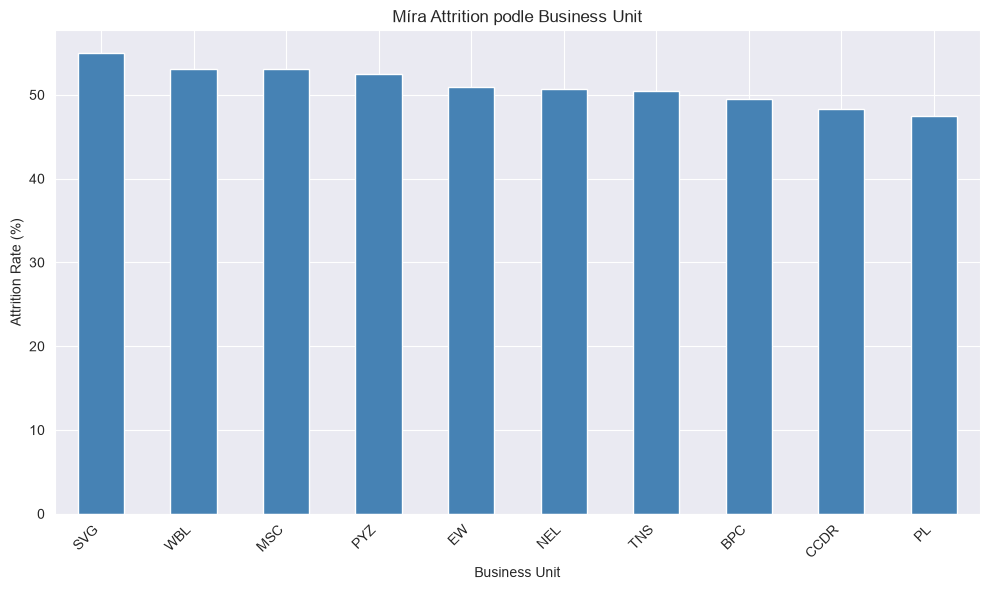

In [5]:
plt.figure(figsize=(10, 6))
attrition_by_unit.plot(kind='bar', color='steelblue')
plt.title('Míra Attrition podle Business Unit')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Business Unit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/attrition_by_business_unit.png', dpi=150)
plt.show()

In [6]:
score_cols = ['Satisfaction Score', 'Engagement Score', 'Work-Life Balance Score']
df.groupby('Attrition')[score_cols].mean()

,Satisfaction Score,Engagement Score,Work-Life Balance Score
Attrition,,,
False,3.034083,2.940695,3.027267
True,3.010437,2.938682,2.952381


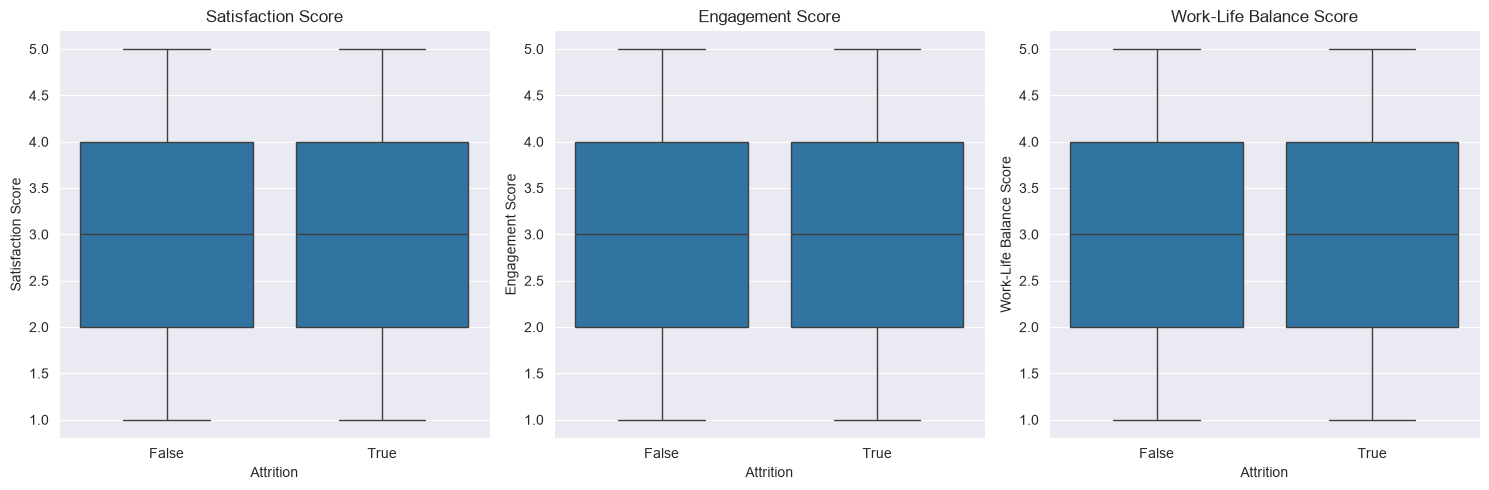

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(score_cols):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('../visuals/attrition_vs_scores.png', dpi=150)
plt.show()

In [8]:
df['Age'] = (pd.Timestamp.now() - df['DOB']).dt.days // 365
df['Tenure_days'] = (df['ExitDate'].fillna(pd.Timestamp.now()) - df['StartDate']).dt.days

df.groupby('Attrition')[['Age', 'Tenure_days']].mean()

,Age,Tenure_days
Attrition,,
False,54.335378,1978.289707
True,54.444879,488.121331


In [9]:
df.groupby('Performance Score')['Attrition'].mean().sort_values(ascending=False) * 100

Performance Score
PIP                  52.688172
Exceeds              51.761518
Needs Improvement    51.412429
Fully Meets          50.910631
Name: Attrition, dtype: float64

In [16]:
supervisor_attrition = df.groupby('Supervisor')['Attrition'].agg(['mean', 'count'])
supervisor_attrition = supervisor_attrition[supervisor_attrition['count'] >= 2]
supervisor_attrition.sort_values('mean', ascending=False).head(10)

,mean,count
Supervisor,,
Angela Bailey,1.0,2
Jessica Peters,1.0,2
Thomas Jackson,1.0,2
Robert Sullivan,1.0,2
Peter Williams,1.0,2
Melissa Torres,1.0,2
Mark Hernandez,1.0,2
Kevin Davis,1.0,2
Joshua Gonzalez,1.0,2
